# Neural Networks - Phase 6

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
# Load Data

train_df = pd.read_csv("data/processed/train_2010_2022.csv")
test_df = pd.read_csv("data/processed/test_2023_2025.csv")

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (120, 17)
Test: (34, 17)


In [3]:
# Define Features and Targets

numeric_features = [
    "draft_pick_overall",
    "age_on_draft_day",
    "height_inches",
    "weight_lbs",
    "college_games_played",
    "career_yards",
    "career_touchdowns"
]

categorical_features = [
    "position"
]

target_regression = "rookie_total_ppr_points"
target_classification = "fantasy_relevant_binary"

In [4]:
# Create X and y

X_train_raw = train_df[numeric_features + categorical_features]
X_test_raw = test_df[numeric_features + categorical_features]

y_train_reg = train_df[target_regression].values
y_test_reg = test_df[target_regression].values

y_train_class = train_df[target_classification].values
y_test_class = test_df[target_classification].values

In [5]:
# Preprocess Data for Neural Networks

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

In [6]:
# Fit only on training data

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print("Processed Train Shape:", X_train.shape)
print("Processed Test Shape:", X_test.shape)

Processed Train Shape: (120, 11)
Processed Test Shape: (34, 11)


In [7]:
# Set Random Seeds

np.random.seed(88)
tf.random.set_seed(88)

In [8]:
# Build Neural Network Regressor

reg_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1)
])

In [9]:
# Compile

reg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mae"]
)

In [13]:
# Add Early Stopping

early_stop_reg = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [14]:
# Train

reg_history = reg_model.fit(
    X_train,
    y_train_reg,
    validation_split=0.20,
    epochs=150,
    batch_size=8,
    callbacks=[early_stop_reg],
    verbose=0
)

print(f"Training stopped after {len(reg_history.history['loss'])} epochs.")

Training stopped after 14 epochs.


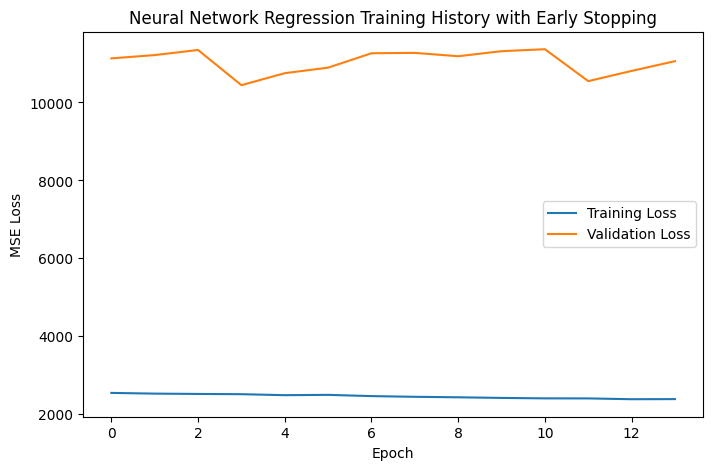

In [15]:
# Plot Regression Training History

plt.figure(figsize=(8, 5))
plt.plot(reg_history.history["loss"], label="Training Loss")
plt.plot(reg_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Neural Network Regression Training History with Early Stopping")
plt.legend()
plt.show()

In [16]:
# Evaluate Neural Network Regressor

nn_reg_preds = reg_model.predict(X_test).flatten()

nn_mae = mean_absolute_error(y_test_reg, nn_reg_preds)
nn_rmse = np.sqrt(mean_squared_error(y_test_reg, nn_reg_preds))

print("Neural Network Regression Results")
print("---------------------------------")
print(f"MAE:  {nn_mae:.2f}")
print(f"RMSE: {nn_rmse:.2f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Neural Network Regression Results
---------------------------------
MAE:  86.06
RMSE: 109.00


In [17]:
# Build Neural Network Classifier

# Set seeds again for reproducibility
np.random.seed(88)
tf.random.set_seed(88)

# Build a small classification neural network
clf_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [18]:
# Compile Neural Network Classifier

clf_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [19]:
# Add Early Stopping for Classifier

early_stop_clf = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [20]:
# Train Neural Network Classifier with Early Stopping

clf_history = clf_model.fit(
    X_train,
    y_train_class,
    validation_split=0.20,
    epochs=150,
    batch_size=8,
    callbacks=[early_stop_clf],
    verbose=0
)

print(f"Training stopped after {len(clf_history.history['loss'])} epochs.")

Training stopped after 22 epochs.


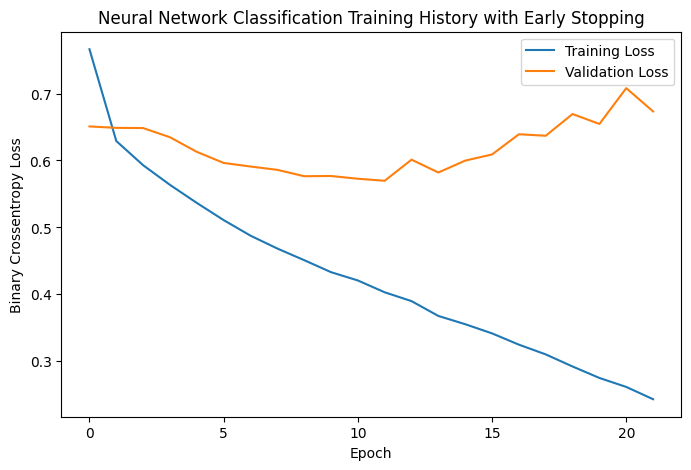

In [21]:
# Plot Classification Triaining History with Early Stopping

plt.figure(figsize=(8, 5))
plt.plot(clf_history.history["loss"], label="Training Loss")
plt.plot(clf_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.title("Neural Network Classification Training History with Early Stopping")
plt.legend()
plt.show()

In [22]:
# Evaluate Neural Network Classifier

nn_class_probs = clf_model.predict(X_test).flatten()
nn_class_preds = (nn_class_probs >= 0.50).astype(int)

nn_accuracy = accuracy_score(y_test_class, nn_class_preds)
nn_precision = precision_score(y_test_class, nn_class_preds, zero_division=0)
nn_recall = recall_score(y_test_class, nn_class_preds, zero_division=0)
nn_f1 = f1_score(y_test_class, nn_class_preds, zero_division=0)
nn_auc = roc_auc_score(y_test_class, nn_class_probs)

print("Neural Network Classification Results")
print("-------------------------------------")
print(f"Accuracy:  {nn_accuracy:.2f}")
print(f"Precision: {nn_precision:.2f}")
print(f"Recall:    {nn_recall:.2f}")
print(f"F1 Score:  {nn_f1:.2f}")
print(f"ROC-AUC:   {nn_auc:.2f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Neural Network Classification Results
-------------------------------------
Accuracy:  0.56
Precision: 0.71
Recall:    0.28
F1 Score:  0.40
ROC-AUC:   0.60


In [24]:
# Neural Network Regression (No Early Stopping)

# Reset seeds
np.random.seed(88)
tf.random.set_seed(88)

nn_reg_no_stop = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1)
])

nn_reg_no_stop.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mae"]
)

history_no_stop_reg = nn_reg_no_stop.fit(
    X_train,
    y_train_reg,
    validation_split=0.20,
    epochs=150,
    batch_size=8,
    verbose=0
)

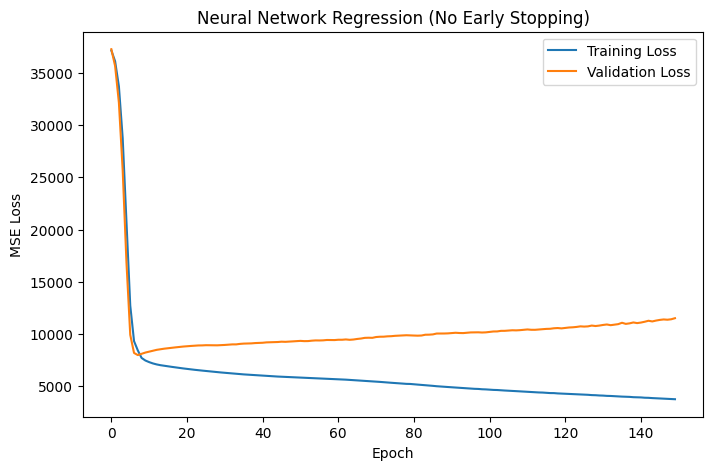

In [33]:
# Plot Neural Network Regression (No Early Stopping)

plt.figure(figsize=(8, 5))

plt.plot(
    history_no_stop_reg.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_no_stop_reg.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "Neural Network Regression (No Early Stopping)"
)

plt.legend()
plt.show()

In [25]:
# Evaluate No-Stop Regression Model

nn_reg_no_stop_preds = nn_reg_no_stop.predict(X_test).flatten()

nn_no_stop_mae = mean_absolute_error(
    y_test_reg,
    nn_reg_no_stop_preds
)

nn_no_stop_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        nn_reg_no_stop_preds
    )
)

print("Neural Network Regression (No Early Stop)")
print("-----------------------------------------")
print(f"MAE: {nn_no_stop_mae:.2f}")
print(f"RMSE: {nn_no_stop_rmse:.2f}")

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001EA81FD36A0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Neural Network Regression (No Early Stop)
-----------------------------------------
MAE: 80.35
RMSE: 98.73


In [26]:
# Neural Network Classifier (No Early Stopping)

# Reset seeds
np.random.seed(88)
tf.random.set_seed(88)

nn_clf_no_stop = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

nn_clf_no_stop.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_no_stop_clf = nn_clf_no_stop.fit(
    X_train,
    y_train_class,
    validation_split=0.20,
    epochs=150,
    batch_size=8,
    verbose=0
)

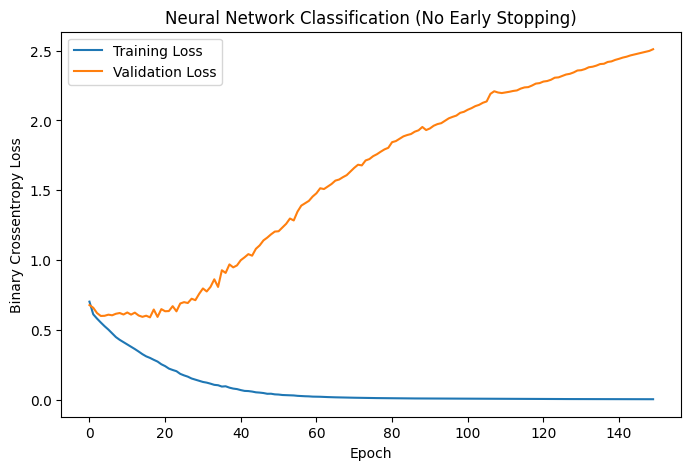

In [34]:
# Plot Neural Network Classification (No Early Stopping)

plt.figure(figsize=(8, 5))

plt.plot(
    history_no_stop_clf.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_no_stop_clf.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")

plt.title(
    "Neural Network Classification (No Early Stopping)"
)

plt.legend()
plt.show()

In [27]:
# Evaluate No-Stop Classifier

nn_no_stop_probs = nn_clf_no_stop.predict(X_test).flatten()

nn_no_stop_preds = (
    nn_no_stop_probs >= 0.50
).astype(int)

nn_no_stop_accuracy = accuracy_score(
    y_test_class,
    nn_no_stop_preds
)

nn_no_stop_precision = precision_score(
    y_test_class,
    nn_no_stop_preds,
    zero_division=0
)

nn_no_stop_recall = recall_score(
    y_test_class,
    nn_no_stop_preds,
    zero_division=0
)

nn_no_stop_f1 = f1_score(
    y_test_class,
    nn_no_stop_preds,
    zero_division=0
)

nn_no_stop_auc = roc_auc_score(
    y_test_class,
    nn_no_stop_probs
)

print("Neural Network Classification (No Early Stop)")
print("---------------------------------------------")
print(f"Accuracy: {nn_no_stop_accuracy:.2f}")
print(f"Precision: {nn_no_stop_precision:.2f}")
print(f"Recall: {nn_no_stop_recall:.2f}")
print(f"F1: {nn_no_stop_f1:.2f}")
print(f"ROC-AUC: {nn_no_stop_auc:.2f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Neural Network Classification (No Early Stop)
---------------------------------------------
Accuracy: 0.53
Precision: 0.56
Recall: 0.50
F1: 0.53
ROC-AUC: 0.56


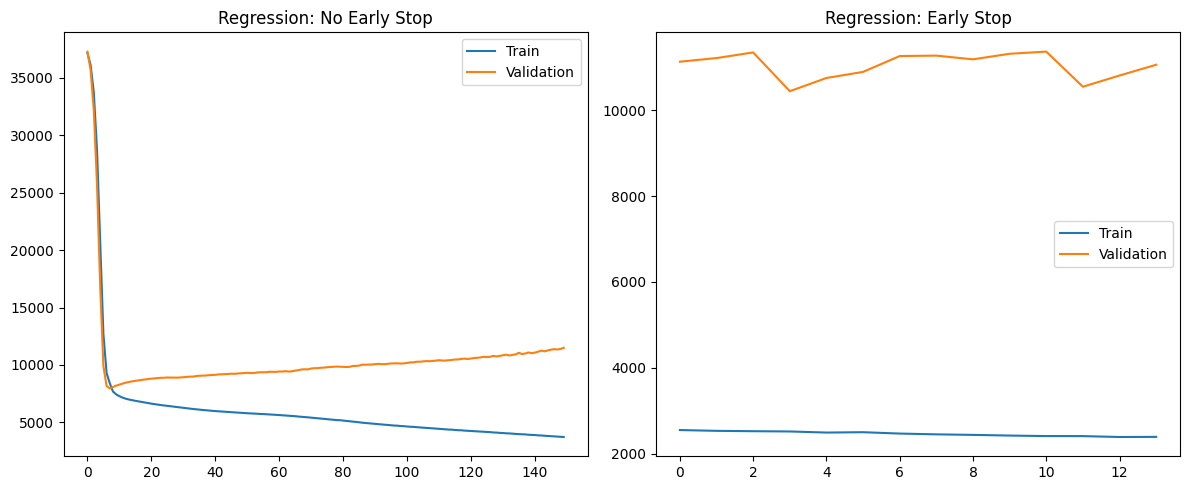

In [35]:
# Side by Side Regression Comparison

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# No stop
ax[0].plot(
    history_no_stop_reg.history["loss"],
    label="Train"
)

ax[0].plot(
    history_no_stop_reg.history["val_loss"],
    label="Validation"
)

ax[0].set_title(
    "Regression: No Early Stop"
)

ax[0].legend()


# Early stop
ax[1].plot(
    reg_history.history["loss"],
    label="Train"
)

ax[1].plot(
    reg_history.history["val_loss"],
    label="Validation"
)

ax[1].set_title(
    "Regression: Early Stop"
)

ax[1].legend()

plt.tight_layout()
plt.show()

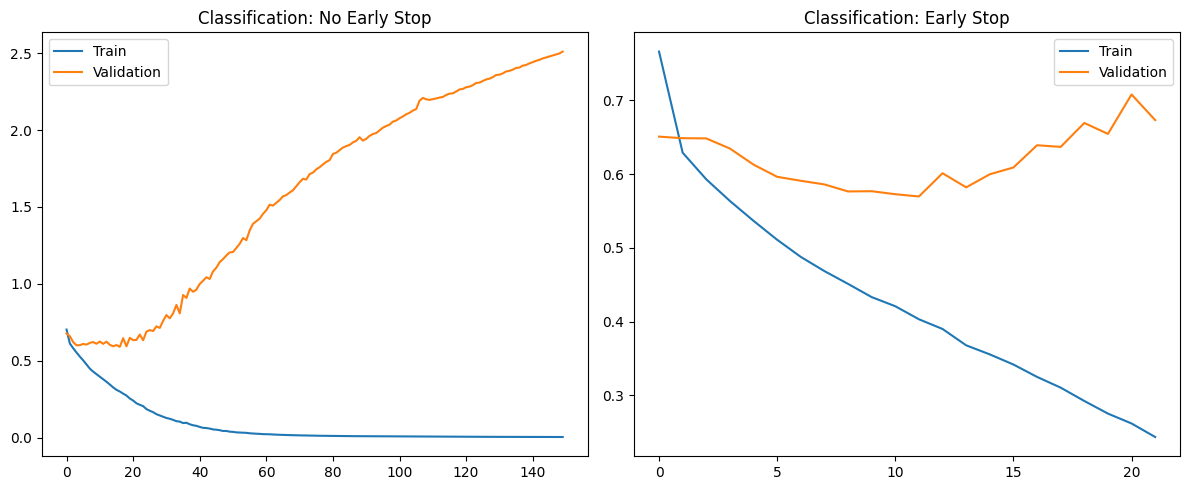

In [36]:
# Side by Side Classification Comparison

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# No stop
ax[0].plot(
    history_no_stop_clf.history["loss"],
    label="Train"
)

ax[0].plot(
    history_no_stop_clf.history["val_loss"],
    label="Validation"
)

ax[0].set_title(
    "Classification: No Early Stop"
)

ax[0].legend()


# Early stop
ax[1].plot(
    clf_history.history["loss"],
    label="Train"
)

ax[1].plot(
    clf_history.history["val_loss"],
    label="Validation"
)

ax[1].set_title(
    "Classification: Early Stop"
)

ax[1].legend()

plt.tight_layout()
plt.show()

In [23]:
# Load Phase 5 Results

phase5_results = pd.read_csv("data/processed/model_results_phase5.csv")
phase5_results

,model,task,MAE,RMSE,Accuracy,Precision,Recall,F1,ROC_AUC
0,Linear Regression,Regression,81.930322,97.200703,NaN,NaN,NaN,NaN,NaN
1,Logistic Regression,Classification,NaN,NaN,0.500000,0.555556,0.277778,0.370370,0.642361
2,Decision Tree Regressor,Regression,77.824500,98.054071,NaN,NaN,NaN,NaN,NaN
3,Random Forest Regressor,Regression,77.043176,94.266681,NaN,NaN,NaN,NaN,NaN
4,Decision Tree Classifier,Classification,NaN,NaN,0.529412,0.666667,0.222222,0.333333,0.666667
5,Random Forest Classifier,Classification,NaN,NaN,0.588235,0.625000,0.555556,0.588235,0.663194


In [28]:
# Add Neural Network Results (With & Without Early Stopping)

nn_results = pd.DataFrame([

    # Early stop regression
    {
        "model": "NN Regressor (Early Stop)",
        "task": "Regression",
        "MAE": nn_mae,
        "RMSE": nn_rmse,
        "Accuracy": np.nan,
        "Precision": np.nan,
        "Recall": np.nan,
        "F1": np.nan,
        "ROC_AUC": np.nan
    },

    # No stop regression
    {
        "model": "NN Regressor (No Stop)",
        "task": "Regression",
        "MAE": nn_no_stop_mae,
        "RMSE": nn_no_stop_rmse,
        "Accuracy": np.nan,
        "Precision": np.nan,
        "Recall": np.nan,
        "F1": np.nan,
        "ROC_AUC": np.nan
    },

    # Early stop classifier
    {
        "model": "NN Classifier (Early Stop)",
        "task": "Classification",
        "MAE": np.nan,
        "RMSE": np.nan,
        "Accuracy": nn_accuracy,
        "Precision": nn_precision,
        "Recall": nn_recall,
        "F1": nn_f1,
        "ROC_AUC": nn_auc
    },

    # No stop classifier
    {
        "model": "NN Classifier (No Stop)",
        "task": "Classification",
        "MAE": np.nan,
        "RMSE": np.nan,
        "Accuracy": nn_no_stop_accuracy,
        "Precision": nn_no_stop_precision,
        "Recall": nn_no_stop_recall,
        "F1": nn_no_stop_f1,
        "ROC_AUC": nn_no_stop_auc
    }

])

all_results_phase6 = pd.concat(
    [phase5_results, nn_results],
    ignore_index=True
)

all_results_phase6

,model,task,MAE,RMSE,Accuracy,Precision,Recall,F1,ROC_AUC
0,Linear Regression,Regression,81.930322,97.200703,NaN,NaN,NaN,NaN,NaN
1,Logistic Regression,Classification,NaN,NaN,0.500000,0.555556,0.277778,0.370370,0.642361
2,Decision Tree Regressor,Regression,77.824500,98.054071,NaN,NaN,NaN,NaN,NaN
3,Random Forest Regressor,Regression,77.043176,94.266681,NaN,NaN,NaN,NaN,NaN
4,Decision Tree Classifier,Classification,NaN,NaN,0.529412,0.666667,0.222222,0.333333,0.666667
5,Random Forest Classifier,Classification,NaN,NaN,0.588235,0.625000,0.555556,0.588235,0.663194
6,NN Regressor (Early Stop),Regression,86.063437,109.002145,NaN,NaN,NaN,NaN,NaN
7,NN Regressor (No Stop),Regression,80.347920,98.729422,NaN,NaN,NaN,NaN,NaN
8,NN Classifier (Early Stop),Classification,NaN,NaN,0.558824,0.714286,0.277778,0.400000,0.597222
9,NN Classifier (No Stop),Classification,NaN,NaN,0.529412,0.562500,0.500000,0.529412,0.555556


In [29]:
# Save Phase 6 Results

all_results_phase6.to_csv("data/processed/model_results_phase6.csv", index=False)

print("Phase 6 results saved.")

Phase 6 results saved.


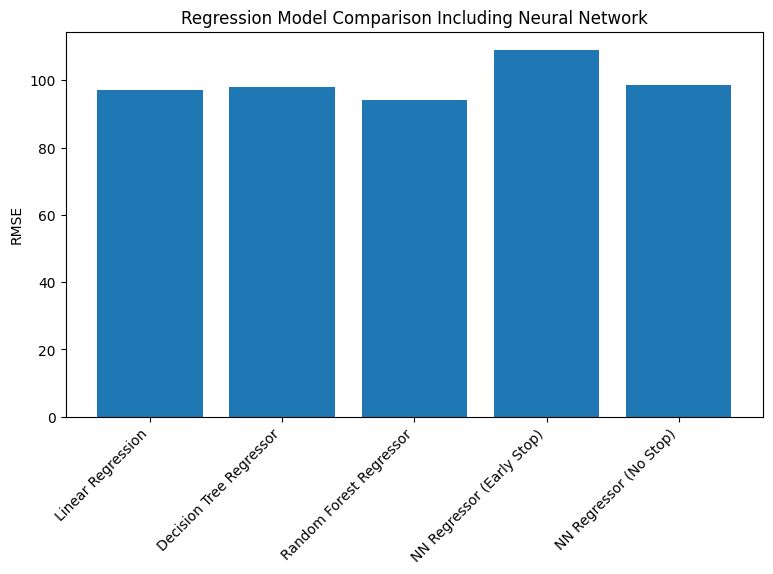

In [30]:
# Regression Comparison Plot

reg_results = all_results_phase6[all_results_phase6["task"] == "Regression"]

plt.figure(figsize=(9, 5))
plt.bar(reg_results["model"], reg_results["RMSE"])
plt.ylabel("RMSE")
plt.title("Regression Model Comparison Including Neural Network")
plt.xticks(rotation=45, ha="right")
plt.show()

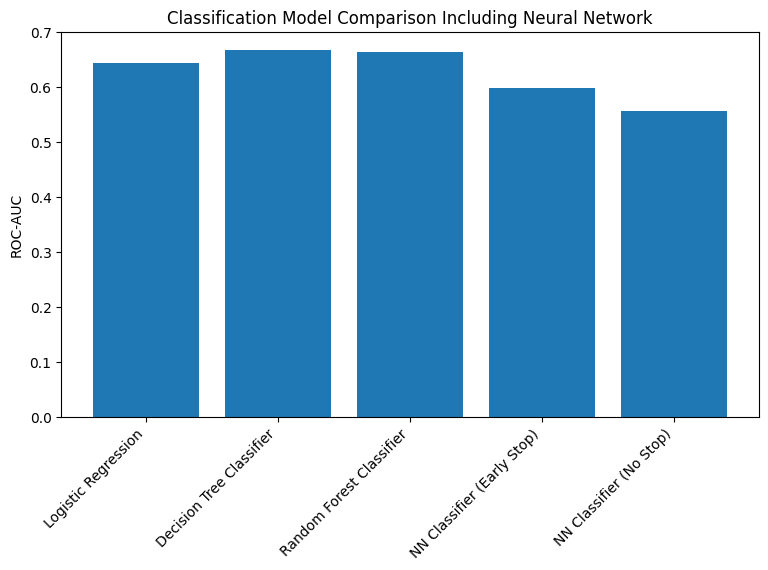

In [31]:
# Classification Comparison Plot

clf_results = all_results_phase6[all_results_phase6["task"] == "Classification"]

plt.figure(figsize=(9, 5))
plt.bar(clf_results["model"], clf_results["ROC_AUC"])
plt.ylabel("ROC-AUC")
plt.title("Classification Model Comparison Including Neural Network")
plt.xticks(rotation=45, ha="right")
plt.show()